## Notebook Overview

This notebook demonstrates various NLP techniques:
*   **Text Preprocessing**: Tokenization, normalization, stop word removal, stemming, lemmatization.
*   **Feature Extraction**: Bag-of-Words (BoW) and TF-IDF.
*   **Text Visualization**: Word Cloud.
*   **N-grams**: Unigrams, bigrams, trigrams.
*   **Word Embeddings**: Custom Word2Vec and pre-trained GloVe.
*   **Text Similarity**: Cosine similarity visualization.

### This cell imports essential libraries for NLP tasks, including `nltk`, `sklearn`, `wordcloud`, `matplotlib`, `seaborn`, `numpy`, `gensim`, `string`, and `re`.

In [ ]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, ne_chunk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from gensim.models import Word2Vec
from gensim.models import KeyedVectors

import string
import re


This cell defines a sample text string for NLP demonstrations.

In [ ]:
text = 'The Pirate Bay allows users to search for Magnet links. These are used to reference resources available for download via peer-to-peer networks which, when opened in a BitTorrent client, begin downloading the desired content.'

This cell generates and displays a word cloud from the `text` variable, showing word frequency visually.

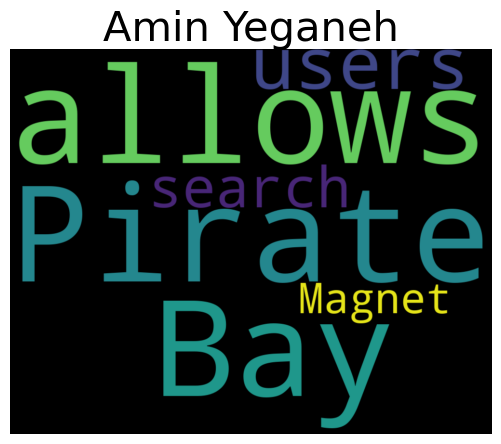

In [ ]:
cloud = WordCloud(width=1000, height=800, max_font_size=500, max_words=6, background_color='black').generate(text[:50])     #wordcloud
plt.figure(figsize=(10,5))
plt.imshow(cloud, interpolation='bilinear')
plt.axis("off")
plt.title('Amin Yeganeh', fontsize='30')
plt.show()

This cell demonstrates the Bag-of-Words (BoW) model using `CountVectorizer` to convert text into token counts.

In [ ]:
bow = CountVectorizer().fit_transform([text])       #bag of words
bow.toarray()

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
        2, 1, 3, 1, 1, 1, 1, 1]])

This cell demonstrates TF-IDF using `TfidfVectorizer` to score word importance, removing common English stop words.

In [ ]:
tfidf = TfidfVectorizer(stop_words='english').fit_transform([text])     #Term Frequency Inverse Document Frequency
tfidf.toarray()

array([[0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
        0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
        0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.40824829,
        0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
        0.20412415]])

This cell defines `text_preprocessing` for tokenization, normalization (lowercase, no punctuation/digits), stop word removal, stemming, lemmatization, POS tagging, and NER.

In [ ]:
def text_preprocessing(txt, english=True):
    #tokenization
    tokens = word_tokenize(txt)
    #normalization
    lowercase = [token.lower() for token in tokens]
    no_punc = [token for token in lowercase if token not in string.punctuation]
    no_digit = [token for token in no_punc if not token.isdigit()]

    no_stop, stemmed, lemmatized, pos_tagged, ner = 5 * ['non-english text']

    if english :
        no_stop = [token for token in no_digit if token not in stopwords.words('english')]       # deleting stopwords

        stemmed = [PorterStemmer().stem(token) for token in no_stop]        # stemming

        lemmatized = [WordNetLemmatizer().lemmatize(token) for token in no_stop]        # lemmatization

        pos_tagged = pos_tag(no_punc)       # pos tagging

        ner = ne_chunk(pos_tagged)      # name entity recognition

    procs = (tokens,
        lowercase,
        no_punc,
        no_digit,
        no_stop,
        stemmed,
        lemmatized,
        pos_tagged,
        ner)

    return procs

This cell defines the `ngrams` function, which preprocesses text and generates n-grams (sequences of `n` words) from the tokens.

In [ ]:
def ngrams(raw_text, n=3):
    if n <= 0:
        raise ValueError
    normalized_text = text_preprocessing(raw_text)[4]

    grams = {}

    for i in range(1, n+1):
        gram_list = []

        for j in range(len(normalized_text) - n+1):
            gram_list.append(normalized_text[j: j+n])

        grams[i] = gram_list
    return grams

This cell calls `ngrams` for unigrams (1-grams), but due to a function error, it currently returns trigrams instead.

In [ ]:
unigrams = ngrams(text)[1]
unigrams

[['pirate', 'bay', 'allows'],
 ['bay', 'allows', 'users'],
 ['allows', 'users', 'search'],
 ['users', 'search', 'magnet'],
 ['search', 'magnet', 'links'],
 ['magnet', 'links', 'used'],
 ['links', 'used', 'reference'],
 ['used', 'reference', 'resources'],
 ['reference', 'resources', 'available'],
 ['resources', 'available', 'download'],
 ['available', 'download', 'via'],
 ['download', 'via', 'peer-to-peer'],
 ['via', 'peer-to-peer', 'networks'],
 ['peer-to-peer', 'networks', 'opened'],
 ['networks', 'opened', 'bittorrent'],
 ['opened', 'bittorrent', 'client'],
 ['bittorrent', 'client', 'begin'],
 ['client', 'begin', 'downloading'],
 ['begin', 'downloading', 'desired'],
 ['downloading', 'desired', 'content']]

This cell calls `ngrams` for bigrams (2-grams), but due to the function's implementation, it also returns trigrams.

In [ ]:
bigrams = ngrams(text)[2]
bigrams

[['pirate', 'bay', 'allows'],
 ['bay', 'allows', 'users'],
 ['allows', 'users', 'search'],
 ['users', 'search', 'magnet'],
 ['search', 'magnet', 'links'],
 ['magnet', 'links', 'used'],
 ['links', 'used', 'reference'],
 ['used', 'reference', 'resources'],
 ['reference', 'resources', 'available'],
 ['resources', 'available', 'download'],
 ['available', 'download', 'via'],
 ['download', 'via', 'peer-to-peer'],
 ['via', 'peer-to-peer', 'networks'],
 ['peer-to-peer', 'networks', 'opened'],
 ['networks', 'opened', 'bittorrent'],
 ['opened', 'bittorrent', 'client'],
 ['bittorrent', 'client', 'begin'],
 ['client', 'begin', 'downloading'],
 ['begin', 'downloading', 'desired'],
 ['downloading', 'desired', 'content']]

This cell calls `ngrams` for trigrams (3-grams), which are correctly displayed by the function.

In [ ]:
trigrams = ngrams(text)[3]
trigrams

[['pirate', 'bay', 'allows'],
 ['bay', 'allows', 'users'],
 ['allows', 'users', 'search'],
 ['users', 'search', 'magnet'],
 ['search', 'magnet', 'links'],
 ['magnet', 'links', 'used'],
 ['links', 'used', 'reference'],
 ['used', 'reference', 'resources'],
 ['reference', 'resources', 'available'],
 ['resources', 'available', 'download'],
 ['available', 'download', 'via'],
 ['download', 'via', 'peer-to-peer'],
 ['via', 'peer-to-peer', 'networks'],
 ['peer-to-peer', 'networks', 'opened'],
 ['networks', 'opened', 'bittorrent'],
 ['opened', 'bittorrent', 'client'],
 ['bittorrent', 'client', 'begin'],
 ['client', 'begin', 'downloading'],
 ['begin', 'downloading', 'desired'],
 ['downloading', 'desired', 'content']]

This cell reads text from 'myText.txt', cleans it, and tokenizes it into sentences.

In [ ]:
with open('myText.txt', 'r') as text:
    text1 = text.read()

text1 = re.sub(r'[^\w\s\.]', '', text1).lower()
# translator = str.maketrans({'\n': '', ',': ''})
# text1 = text1.translate(translator)
text1 = sent_tokenize(text1)
text1

['steven paul jobs february 24 1955  october 5 2011 was an american business magnate inventor and investor.',
 'he was the cofounder chairman and ceo of apple the chairman and majority shareholder of pixar a member of the walt disney companys board of directors following its acquisition of pixar and the founder chairman and ceo of next.',
 'he was a pioneer of the personal computer revolution of the 1970s and 1980s along with his early business partner and fellow apple cofounder steve wozniak.',
 'jobs was born in san francisco to a syrian father and germanamerican mother.',
 'he was adopted shortly after his birth.',
 'jobs attended reed college in 1972 before withdrawing that same year.',
 'in 1974 he traveled through india seeking enlightenment before later studying zen buddhism.',
 'he and wozniak cofounded apple in 1976 to sell wozniaks apple i personal computer.',
 'together the duo gained fame and wealth a year later with production and sale of the apple ii one of the first high

This cell preprocesses each sentence from 'myText.txt' using `text_preprocessing` and stores the tokens for Word2Vec training.

In [ ]:
sentences = []
for sentence in text1:
    sentences.append(text_preprocessing(sentence)[0])

This cell trains a custom Word2Vec model on the preprocessed sentences to learn word embeddings.

In [ ]:
model = Word2Vec(
                sentences,
                vector_size=100,
                window=5,
                min_count=1,
                workers=4,              # !! cpu cores
                sg=0,
                epochs=200
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


This cell prints the total number of unique words (vocabulary size) in the trained Word2Vec model.

In [ ]:
print(f"کلمات : {len(model.wv)}")

کلمات : 264


This cell demonstrates finding similar words using the custom Word2Vec model, noting its performance limitation due to small text size.

In [ ]:
words_to_check = ['jobs', 'business', 'freedom', 'computer', 'jobs']

for w in words_to_check:
    if w in model.wv:
        print(f" {w} exists")
        similar = model.wv.most_similar(w, topn=3)
        print(f"   smilarities: {similar}")
    else:
        print(f"{w} does not exist")


# بخاطر حجم کم متن مدل خوب اموزش نمیبینه
# پس بهتره از مدل های آماده استفاده کرد

 jobs exists
   smilarities: [('neuroendocrine', 0.9925795197486877), ('pancreatic', 0.9925594329833984), ('mother', 0.9919888973236084)]
 business exists
   smilarities: [('early', 0.9923495650291443), ('magnate', 0.9921644926071167), ('partner', 0.9920936226844788)]
 freedom exists
   smilarities: [('presidential', 0.9971898794174194), ('awarded', 0.9969633221626282), ('posthumously', 0.9965093731880188)]
 computer exists
   smilarities: [('personal', 0.9925788640975952), ('i', 0.9909695386886597), ('graphics', 0.9905804991722107)]
 jobs exists
   smilarities: [('neuroendocrine', 0.9925795197486877), ('pancreatic', 0.9925594329833984), ('mother', 0.9919888973236084)]


This cell loads a pre-trained GloVe model ('glove.6B.50d.txt') for word embeddings.

In [ ]:
glove_model = KeyedVectors.load_word2vec_format('glove.6B.50d.txt', binary=False, no_header=True)

# This cell demonstrates finding similar words using the pre-trained GloVe model, showcasing its effectiveness.

In [ ]:
words_to_check = ['amin', 'jobs', 'business', 'freedom', 'computer']

for w in words_to_check:
    if w in glove_model:
        similar = glove_model.most_similar(w, topn=5)
        print(f"\n{w}:")
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.4f}")



amin:
  mohammed: 0.7877
  jamil: 0.7846
  mohamed: 0.7566
  idi: 0.7278
  zahir: 0.7257

jobs:
  employees: 0.8154
  workers: 0.8150
  costs: 0.7988
  job: 0.7953
  workforce: 0.7862

business:
  industry: 0.8721
  companies: 0.8479
  marketing: 0.8375
  corporate: 0.8369
  private: 0.8361

freedom:
  rights: 0.8570
  democracy: 0.8209
  respect: 0.8154
  freedoms: 0.8151
  independence: 0.7844

computer:
  computers: 0.9165
  software: 0.8815
  technology: 0.8526
  electronic: 0.8126
  internet: 0.8060


# This cell defines `line_vector` to convert text lines into single averaged word embedding vectors from GloVe.

In [ ]:
def line_vector(line, model):            # محاسبه بردار برای هر خط در متن اصلی
    words = text_preprocessing(line)[4]
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)
text1_vectors = [line_vector(l, glove_model) for l in text1]


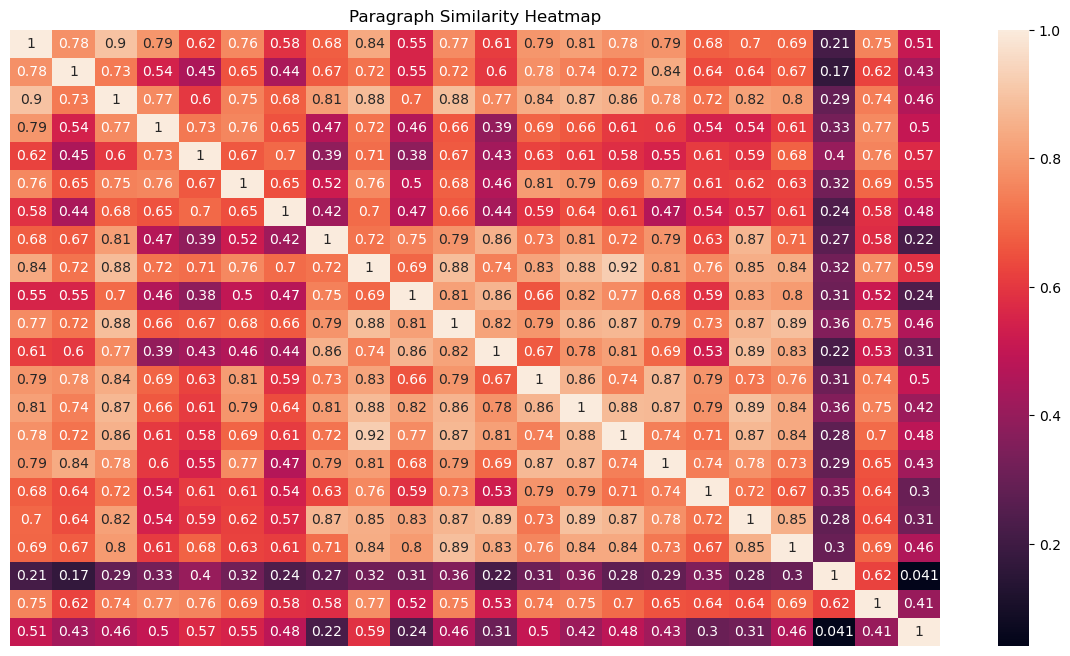

In [ ]:
sim_matrix = cosine_similarity(text1_vectors)       # مقایسه شباهت خطوط با هیت مپ
plt.figure(figsize=(15,8))
sns.heatmap(sim_matrix, annot=True, xticklabels=False, yticklabels=False)
plt.title("Paragraph Similarity Heatmap")
plt.show()